In [ ]:
SSSimport pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import ttest_ind, f_oneway


LOAD THE DATASET

In [ ]:
df = pd.read_csv("/content/global_air_quality_dataset.csv")
df.head()


,Date,City,Country,AQI,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (ppb),SO2 (ppb),CO (ppm),O3 (ppb),Temperature (°C),Humidity (%),Wind Speed (m/s)
0,1/1/2024,New York,USA,38,120.0,182.9,24.3,26.0,9.10,153.3,18.6,40,13.2
1,1/1/2024,Los Angeles,USA,280,38.4,46.9,41.8,34.7,3.78,190.7,-2.2,59,9.5
2,1/1/2024,London,UK,117,168.1,34.3,81.5,8.2,3.67,105.4,36.3,62,3.4
3,1/1/2024,Beijing,China,197,96.8,35.4,18.5,39.4,9.51,92.8,29.9,32,1.8
4,1/1/2024,Delhi,India,187,76.2,226.8,46.9,17.2,1.02,68.4,9.9,55,3.3


UNDERSTAND DATA

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3660 entries, 0 to 3659
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              3660 non-null   object 
 1   City              3660 non-null   object 
 2   Country           3660 non-null   object 
 3   AQI               3660 non-null   int64  
 4   PM2.5 (µg/m³)     3660 non-null   float64
 5   PM10 (µg/m³)      3660 non-null   float64
 6   NO2 (ppb)         3660 non-null   float64
 7   SO2 (ppb)         3660 non-null   float64
 8   CO (ppm)          3660 non-null   float64
 9   O3 (ppb)          3660 non-null   float64
 10  Temperature (°C)  3660 non-null   float64
 11  Humidity (%)      3660 non-null   int64  
 12  Wind Speed (m/s)  3660 non-null   float64
dtypes: float64(8), int64(2), object(3)
memory usage: 371.8+ KB


In [ ]:
df.describe()


,AQI,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (ppb),SO2 (ppb),CO (ppm),O3 (ppb),Temperature (°C),Humidity (%),Wind Speed (m/s)
count,3660.000000,3660.000000,3660.000000,3660.000000,3660.000000,3660.000000,3660.000000,3660.000000,3660.000000,3660.000000
mean,164.642077,126.380574,154.785956,52.960710,25.940328,5.023842,105.325929,15.061913,50.657104,7.788907
std,78.571659,71.016089,84.045548,27.361413,14.001531,2.851573,55.032175,14.590761,23.195880,4.223788
min,30.000000,5.100000,10.000000,5.100000,2.000000,0.100000,10.100000,-10.000000,10.000000,0.500000
25%,96.000000,63.700000,82.200000,29.175000,13.700000,2.590000,57.900000,2.175000,31.000000,4.100000
50%,165.000000,125.850000,152.550000,52.800000,26.200000,4.910000,105.750000,15.000000,51.000000,7.800000
75%,233.000000,187.000000,227.600000,76.700000,38.200000,7.560000,152.925000,27.525000,71.000000,11.500000
max,300.000000,250.000000,300.000000,100.000000,50.000000,9.990000,200.000000,40.000000,90.000000,15.000000


DATA CLEANING

Check missing values

In [ ]:
df.isnull().sum()


,0
Date,0
City,0
Country,0
AQI,0
PM2.5 (µg/m³),0
PM10 (µg/m³),0
NO2 (ppb),0
SO2 (ppb),0
CO (ppm),0
O3 (ppb),0


CREATE TARGET VARIABLE

In [ ]:
def classify_aqi(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Moderate"
    elif aqi <= 200:
        return "Unhealthy"
    else:
        return "Very Unhealthy"

df["AQI_Category"] = df["AQI"].apply(classify_aqi)
df.head()


,Date,City,Country,AQI,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (ppb),SO2 (ppb),CO (ppm),O3 (ppb),Temperature (°C),Humidity (%),Wind Speed (m/s),AQI_Category
0,1/1/2024,New York,USA,38,120.0,182.9,24.3,26.0,9.10,153.3,18.6,40,13.2,Good
1,1/1/2024,Los Angeles,USA,280,38.4,46.9,41.8,34.7,3.78,190.7,-2.2,59,9.5,Very Unhealthy
2,1/1/2024,London,UK,117,168.1,34.3,81.5,8.2,3.67,105.4,36.3,62,3.4,Unhealthy
3,1/1/2024,Beijing,China,197,96.8,35.4,18.5,39.4,9.51,92.8,29.9,32,1.8,Unhealthy
4,1/1/2024,Delhi,India,187,76.2,226.8,46.9,17.2,1.02,68.4,9.9,55,3.3,Unhealthy


ENCODE TARGET VARIABLE--------
ML models only understand numbers, not words.

In [ ]:
le = LabelEncoder()
df["AQI_Category_Encoded"] = le.fit_transform(df["AQI_Category"])


EXPLORATORY DATA ANALYSIS (EDA)

AQI Category Distribution

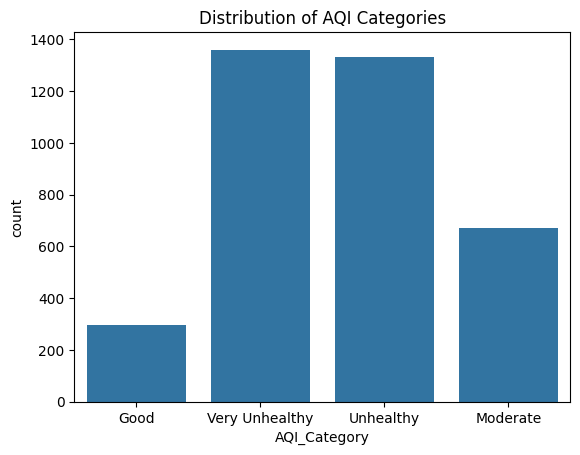

In [ ]:
sns.countplot(x="AQI_Category", data=df)
plt.title("Distribution of AQI Categories")
plt.show()


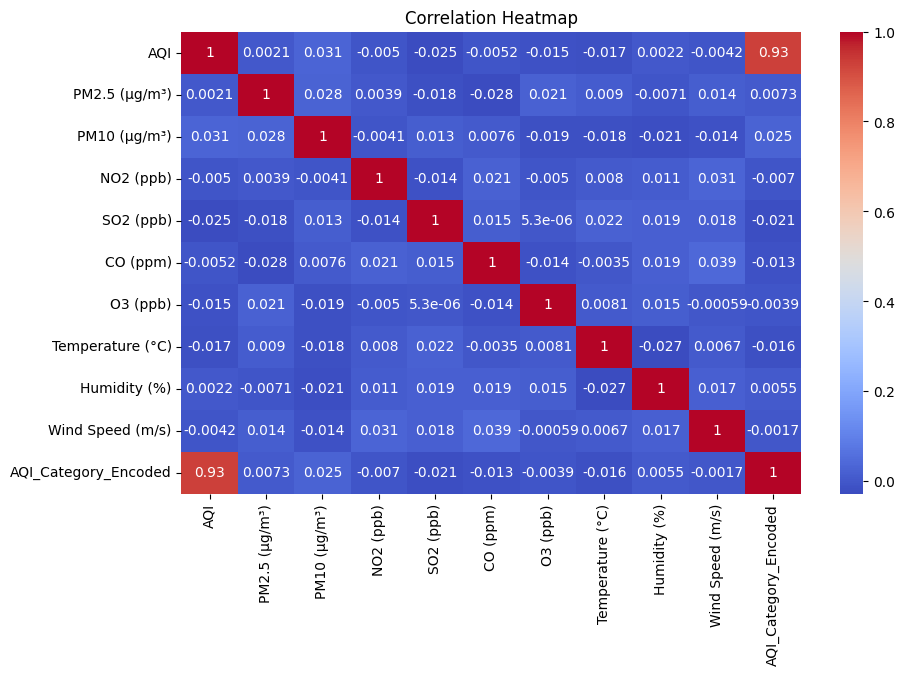

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


CREATE BINARY TARGET

In [ ]:
df["AQI_Binary"] = df["AQI_Category"].apply(
    lambda x: 0 if x in ["Good", "Moderate"] else 1
)


In [ ]:
X = df[['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (ppb)', 'SO2 (ppb)',
        'CO (ppm)', 'O3 (ppb)', 'Temperature (°C)',
        'Humidity (%)', 'Wind Speed (m/s)']]

y = df["AQI_Binary"]


TRAIN-TEST SPLIT

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


SCALE DATA

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


LOGISTIC REGRESSION

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

lr = LogisticRegression(class_weight="balanced", max_iter=2000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Logistic Regression Results")
print(classification_report(y_test, y_pred_lr))
print("Accuracy:", accuracy_score(y_test, y_pred_lr))


Logistic Regression Results
              precision    recall  f1-score   support

           0       0.24      0.46      0.31       194
           1       0.71      0.46      0.56       538

    accuracy                           0.46       732
   macro avg       0.47      0.46      0.44       732
weighted avg       0.58      0.46      0.49       732

Accuracy: 0.46311475409836067


RANDOM FOREST

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Results")
print(classification_report(y_test, y_pred_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))


Random Forest Results
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       194
           1       0.73      1.00      0.85       538

    accuracy                           0.73       732
   macro avg       0.37      0.50      0.42       732
weighted avg       0.54      0.73      0.62       732

Accuracy: 0.7336065573770492


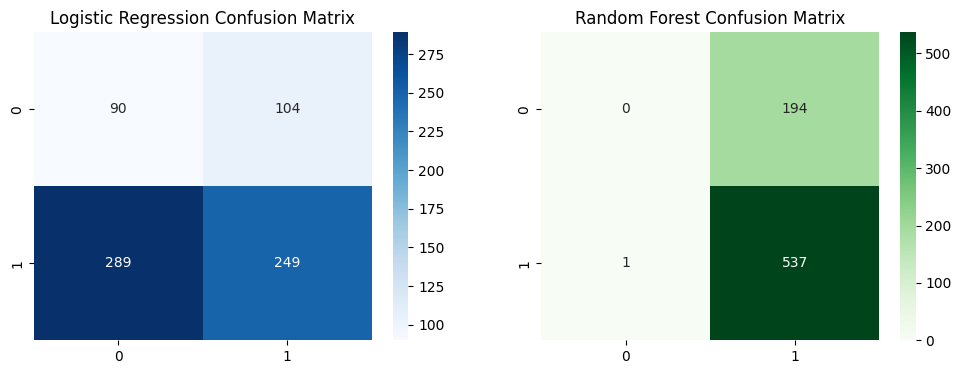

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.heatmap(confusion_matrix(y_test, y_pred_lr),
            annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")

plt.subplot(1,2,2)
sns.heatmap(confusion_matrix(y_test, y_pred_rf),
            annot=True, fmt="d", cmap="Greens")
plt.title("Random Forest Confusion Matrix")

plt.show()


ACCURACY COMPARISON TABLE

In [ ]:
accuracy_table = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy (%)": [
        accuracy_score(y_test, y_pred_lr) * 100,
        accuracy_score(y_test, y_pred_rf) * 100
    ]
})

accuracy_table


,Model,Accuracy (%)
0,Logistic Regression,46.311475
1,Random Forest,73.360656


T-TEST

In [ ]:
from scipy.stats import ttest_ind

safe_pm25 = df[df["AQI_Binary"] == 0]["PM2.5 (µg/m³)"]
unsafe_pm25 = df[df["AQI_Binary"] == 1]["PM2.5 (µg/m³)"]

t_stat, p_value = ttest_ind(safe_pm25, unsafe_pm25, equal_var=False)

t_stat, p_value


(np.float64(-0.06885751084709212), np.float64(0.9451112763006835))

ANOVA / F-TEST (MANDATORY)

In [ ]:
from scipy.stats import f_oneway

f_stat, p_val = f_oneway(
    df[df["AQI_Category"] == "Good"]["PM2.5 (µg/m³)"],
    df[df["AQI_Category"] == "Moderate"]["PM2.5 (µg/m³)"],
    df[df["AQI_Category"] == "Unhealthy"]["PM2.5 (µg/m³)"],
    df[df["AQI_Category"] == "Very Unhealthy"]["PM2.5 (µg/m³)"]
)

f_stat, p_val


(np.float64(0.593274339762401), np.float64(0.6193769671315518))

OPTIONAL VISUAL

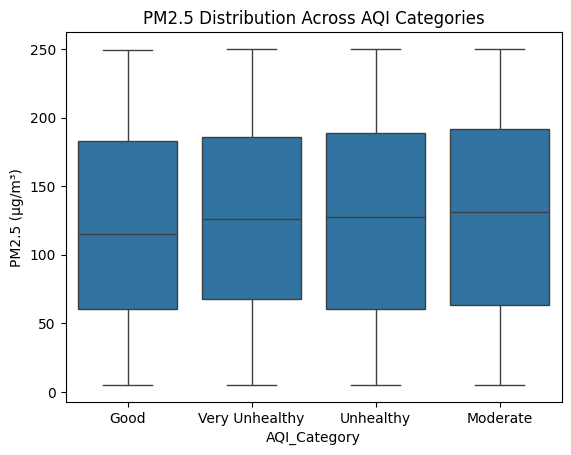

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="AQI_Category", y="PM2.5 (µg/m³)", data=df)
plt.title("PM2.5 Distribution Across AQI Categories")
plt.show()


In [ ]:
import pandas as pd


In [ ]:
df = pd.read_csv("global_air_quality_dataset.csv")


In [ ]:
df.head()

,Date,City,Country,AQI,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (ppb),SO2 (ppb),CO (ppm),O3 (ppb),Temperature (°C),Humidity (%),Wind Speed (m/s)
0,2024-01-01,New York,USA,38,120.0,182.9,24.3,26.0,9.10,153.3,18.6,40,13.2
1,2024-01-01,Los Angeles,USA,280,38.4,46.9,41.8,34.7,3.78,190.7,-2.2,59,9.5
2,2024-01-01,London,UK,117,168.1,34.3,81.5,8.2,3.67,105.4,36.3,62,3.4
3,2024-01-01,Beijing,China,197,96.8,35.4,18.5,39.4,9.51,92.8,29.9,32,1.8
4,2024-01-01,Delhi,India,187,76.2,226.8,46.9,17.2,1.02,68.4,9.9,55,3.3


In [ ]:
def categorize_aqi(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Moderate"
    elif aqi <= 200:
        return "Unhealthy"
    else:
        return "Very Unhealthy"

df["AQI_Category"] = df["AQI"].apply(categorize_aqi)
